In [15]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [16]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

print(df.head())
print(df.info())

Saving Dataset_link.zip to Dataset_link.zip
   Student ID           Name  Gender  Age  GPA             Major  \
0           1     John Smith    Male   21  3.5  Computer Science   
1           2  Alice Johnson  Female   20  3.2  Computer Science   
2           3   Robert Davis    Male   22  3.8  Computer Science   
3           4   Emily Wilson  Female   21  3.7  Computer Science   
4           5  Michael Brown    Male   23  3.4  Computer Science   

         Interested Domain             Projects                 Future Career  \
0  Artificial Intelligence  Chatbot Development   Machine Learning Researcher   
1             Data Science       Data Analytics                Data Scientist   
2     Software Development   E-commerce Website             Software Engineer   
3          Web Development   Full-Stack Web App                 Web Developer   
4            Cybersecurity     Network Security  Information Security Analyst   

    Python     SQL     Java  
0   Strong  Strong     Weak  


In [17]:
df = df.drop(['Student ID', 'Name'], axis=1)

# Handle missing values
df = df.dropna()

In [18]:
X = df.drop('Interested Domain', axis=1)
y = df['Interested Domain']

In [19]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        encoders[col] = le

# Encode output separately
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(len(set(y)), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.0609 - loss: 3.3139 - val_accuracy: 0.0345 - val_loss: 3.2742
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1043 - loss: 3.2673 - val_accuracy: 0.1034 - val_loss: 3.2581
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1304 - loss: 3.2291 - val_accuracy: 0.1034 - val_loss: 3.2445
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1391 - loss: 3.1908 - val_accuracy: 0.1034 - val_loss: 3.2286
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1304 - loss: 3.1528 - val_accuracy: 0.1034 - val_loss: 3.2134
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1565 - loss: 3.1150 - val_accuracy: 0.1034 - val_loss: 3.1971
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1739 - loss: 3.0740 - val_accuracy: 0.1034 - val_loss: 3.1786
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1739 - loss: 3.0313 - val_accuracy: 0.1034 - val_lo

In [24]:
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3889 - loss: 2.0630

Test Accuracy: 0.3888888955116272


In [25]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           4       0.44      0.80      0.57         5
           5       0.00      0.00      0.00         2
           7       0.30      1.00      0.46         3
          10       0.50      0.50      0.50         2
          11       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         1
          18       0.00      0.00      0.00         1
          19       1.00      0.50      0.67         2
          20       0.00      0.00      0.00        10
          24       0.00      0.00      0.00         0
          26       1.00      1.00      1.00         5

    accuracy                           0.39        36
   macro avg       0.23      0.27      0.23        36
weighted avg       0.31      0.39      0.32        36



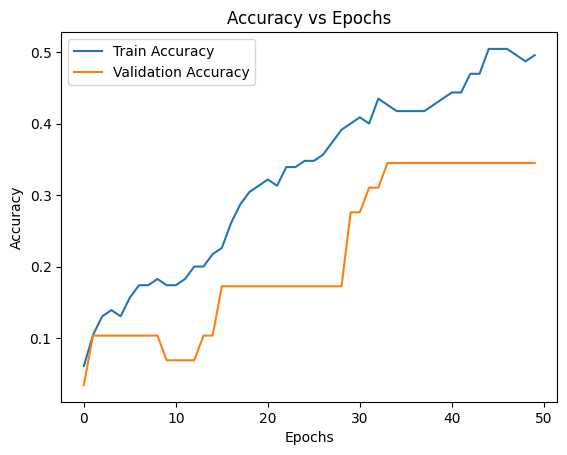

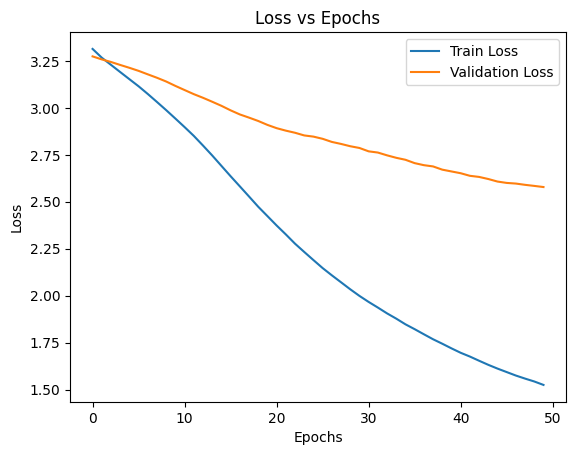

In [27]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
